<a href="https://colab.research.google.com/github/fiametahagos07/CSCE-5575-HW-2-Template/blob/master/fmh0047_Assignment3_AssociationRuleMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [ ]:
# write your answer here

from google.colab import files
uploaded = files.upload()

Saving bread_basket.csv to bread_basket.csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [ ]:
# write your answer here
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings
warnings.filterwarnings("ignore")



In [ ]:

#List Variables and Their dtypes

pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

,Column,Data Type
0,transaction,int64
1,item,object
2,date_time,object
3,time,object
4,period_day,object
5,weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [ ]:
# write your answer here
#Use describe(include='all')

df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

In [ ]:
print(df.columns.tolist())

['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("\ufeff", "", regex=False)
print(df.columns.tolist())

['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


In [ ]:
# Make a lowercase map of columns -> original columns
col_map = {c.lower(): c for c in df.columns}

# If columns exist under different casing, map them
if "item" in col_map and col_map["item"] != "Item":
    df = df.rename(columns={col_map["item"]: "Item"})
if "transaction" in col_map and col_map["transaction"] != "Transaction":
    df = df.rename(columns={col_map["transaction"]: "Transaction"})

print(df.columns.tolist())

['Transaction', 'Item', 'date_time', 'time', 'period_day', 'weekday_weekend']


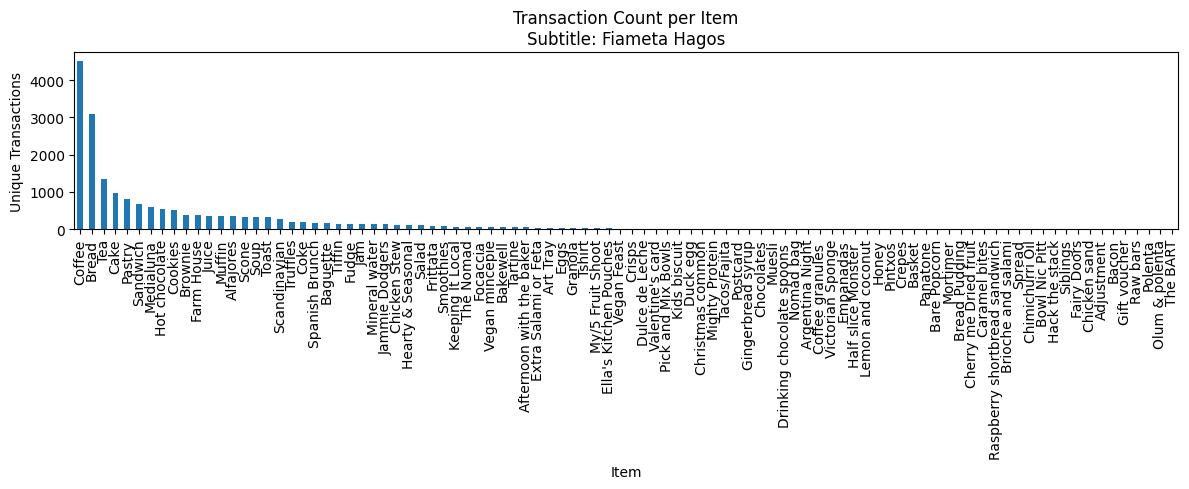

In [ ]:
# c) Bar plot of transaction counts per item
# subtitle = " "  # <-- EDIT THIS
# item_counts =  # <-- EDIT THIS

subtitle = "Fiameta Hagos"

item_counts = (
    df.groupby("Item")["Transaction"]
      .nunique()
      .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [ ]:
# write your answer here
#Get Counts for Specific Items

items_to_check = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

counts = (
    df[df["Item"].isin(items_to_check)]
      .groupby("Item")["Transaction"]
      .nunique()
)

counts

,Transaction
Item,
Alfajores,344
Chicken Stew,123
Coffee,4528
Juice,365
Tea,1350


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [ ]:
# write your answer here
!pip install mlxtend

In [ ]:
#Load & Clean Data

df = pd.read_csv("bread_basket.csv")

# clean column names (VERY IMPORTANT)
df.columns = df.columns.str.strip()

df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [ ]:
# write your answer here

metric="confidence",
min_threshold=0.5

In [ ]:
import pandas as pd

df = pd.read_csv("bread_basket (2).csv")
print(df.columns.tolist())
df.head()

['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [ ]:
# Clean weird spaces and hidden characters
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace("\ufeff", "", regex=False)
)

# Build a case-insensitive map
col_map = {c.lower(): c for c in df.columns}

# Auto-rename common variants to the exact names the notebook expects
if "transaction" not in df.columns:
    if "transaction" in col_map:
        df = df.rename(columns={col_map["transaction"]: "Transaction"})
    elif "transactionno" in col_map:
        df = df.rename(columns={col_map["transactionno"]: "Transaction"})
    elif "trans" in col_map:
        df = df.rename(columns={col_map["trans"]: "Transaction"})

if "item" not in df.columns:
    if "item" in col_map:
        df = df.rename(columns={col_map["item"]: "Item"})
    elif "items" in col_map:
        df = df.rename(columns={col_map["items"]: "Item"})

print("Fixed columns:", df.columns.tolist())

Fixed columns: ['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


In [ ]:
print(df.columns.tolist())

['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


In [ ]:
import os
[f for f in os.listdir() if "bread_basket" in f.lower()]

['bread_basket (2).csv', 'bread_basket.csv', 'bread_basket (1).csv']

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

The rule {Coffee, Cake} ⇒ {Bread} means that customers who buy coffee and cake often also buy bread. The support value is the fraction of all transactions that include coffee, cake, and bread together. The confidence value tells us, among transactions that contain coffee and cake, what proportion also include bread. Because the lift is greater than 1, bread is more likely to be purchased when coffee and cake are purchased together than in an average transaction, suggesting a useful cross-selling/bundling opportunity (e.g., recommend bread or place bread near coffee/cake displays).